### Step 1: Imports & Setup

We need pandas for data manipulation, joblib to load our trained model, and matplotlib/seaborn to visualize the revenue curve.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for our charts
sns.set_theme(style="whitegrid")

### Step 2: Load the Brain

We load the entire Random Forest pipeline (which includes the Target Encoder and StandardScaler) that we tracked with DVC.

In [2]:
model_path = '../models/demand_prediction_model.pkl'

try:
    rf_model = joblib.load(model_path)
    print("✅ Model successfully loaded!")
except FileNotFoundError:
    print(f"❌ Error: Could not find model at {model_path}. Make sure the path is correct.")

✅ Model successfully loaded!


### Step 3: The Optimization Function
This function takes a product's details, simulates a range of different prices, calculates the expected revenue ($Price \times Demand$) for each, and plots the results.

In [3]:
def recommend_optimal_price(product_profile, model, min_price, max_price, step_size=1.0):
    """
    Simulates different prices for a product to find the revenue-maximizing sweet spot.
    """
    # 1. Create a list of test prices
    test_prices = np.arange(min_price, max_price + step_size, step_size)

    # 2. Create a DataFrame where every row is this exact product
    # Repeat the product profile for as many prices as we are testing
    simulation_df = pd.DataFrame([product_profile] * len(test_prices))

    # 3. Inject our test prices into the 'price' column
    simulation_df['price'] = test_prices

    # 4. Ask the model to predict demand for every single price point
    predicted_demands = model.predict(simulation_df)
    simulation_df['predicted_demand'] = predicted_demands

    # 5. Calculate Revenue (Price * Demand)
    simulation_df['expected_revenue'] = simulation_df['price'] * simulation_df['predicted_demand']

    # 6. Find the absolute peak
    best_scenario = simulation_df.loc[simulation_df['expected_revenue'].idxmax()]
    optimal_price = best_scenario['price']
    max_revenue = best_scenario['expected_revenue']
    expected_demand = best_scenario['predicted_demand']

    # --- Visualization ---
    plt.figure(figsize=(12, 6))

    # Plot Revenue Curve
    sns.lineplot(x='price', y='expected_revenue', data=simulation_df,
                 color='green', linewidth=2.5, label='Expected Revenue')

    # Highlight the Sweet Spot
    plt.axvline(x=optimal_price, color='red', linestyle='--', alpha=0.7)
    plt.plot(optimal_price, max_revenue, marker='o', markersize=10, color='red')

    # Formatting
    plt.title('Price vs. Revenue Simulation', fontsize=16)
    plt.xlabel('Tested Price ($)', fontsize=12)
    plt.ylabel('Expected Revenue ($)', fontsize=12)
    plt.annotate(f' Optimal Price: ${optimal_price:.2f}\n Max Revenue: ${max_revenue:,.2f}',
                 xy=(optimal_price, max_revenue),
                 xytext=(optimal_price + (max_price-min_price)*0.05, max_revenue * 0.95),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                 fontsize=12, backgroundcolor='white')

    plt.legend()
    plt.tight_layout()
    plt.show()

    return simulation_df, best_scenario

### Step 4: Test the Engine

Let's create a hypothetical scenario: A specific store selling electronics in a Tier 1 city.
We want to know the best price to set for this item to maximize our revenue.

Running simulation for Electronics in Tier 1 (Major)...


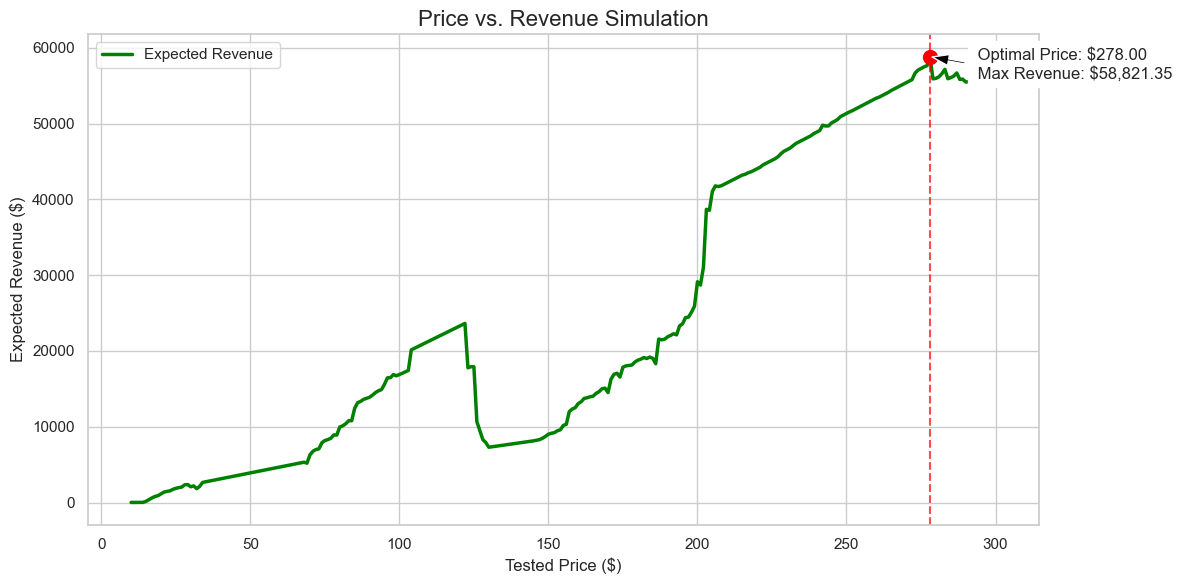

------------------------------
🏆 SIMULATION RESULTS 🏆
Optimal Price: $278.00
Expected Demand: 212 units
Maximum Expected Revenue: $58,821.35
------------------------------


In [4]:
# Define the product and context (Must match the exact column names from our training data)
sample_product = {
    'store_id': 15,           # We can use any store_id; the Target Encoder handles it!
    'category': 'Electronics',
    'subcategory': 'Phones',
    'country': 'South Africa',
    'city_tier': 'Tier 1 (Major)',
    'year': 2024,
    'month': 11,                      # E.g., November (holiday shopping)
    'day_of_week': 5,                 # Saturday
    'is_weekend': 1                   # Yes, it's a weekend
}

print(f"Running simulation for {sample_product['category']} in {sample_product['city_tier']}...")

# Run the function: Test prices from $10 to $100, in $1 increments
results_df, best_result = recommend_optimal_price(
    product_profile=sample_product,
    model=rf_model,
    min_price=10.0,
    max_price=300.0,
    step_size=1.0
)

print("-" * 30)
print("🏆 SIMULATION RESULTS 🏆")
print(f"Optimal Price: ${best_result['price']:.2f}")
print(f"Expected Demand: {best_result['predicted_demand']:.0f} units")
print(f"Maximum Expected Revenue: ${best_result['expected_revenue']:,.2f}")
print("-" * 30)

### Step 5: Bounded Simulation (Sanity Check)

We need to look at our historical data to find the actual price boundaries, for this specific subcategory to prevent the model from hallucinating.


--- Historical Data for Phones ---
Lowest price ever sold: $155.35
Highest price ever sold: $1282.82
---------------------------------------------


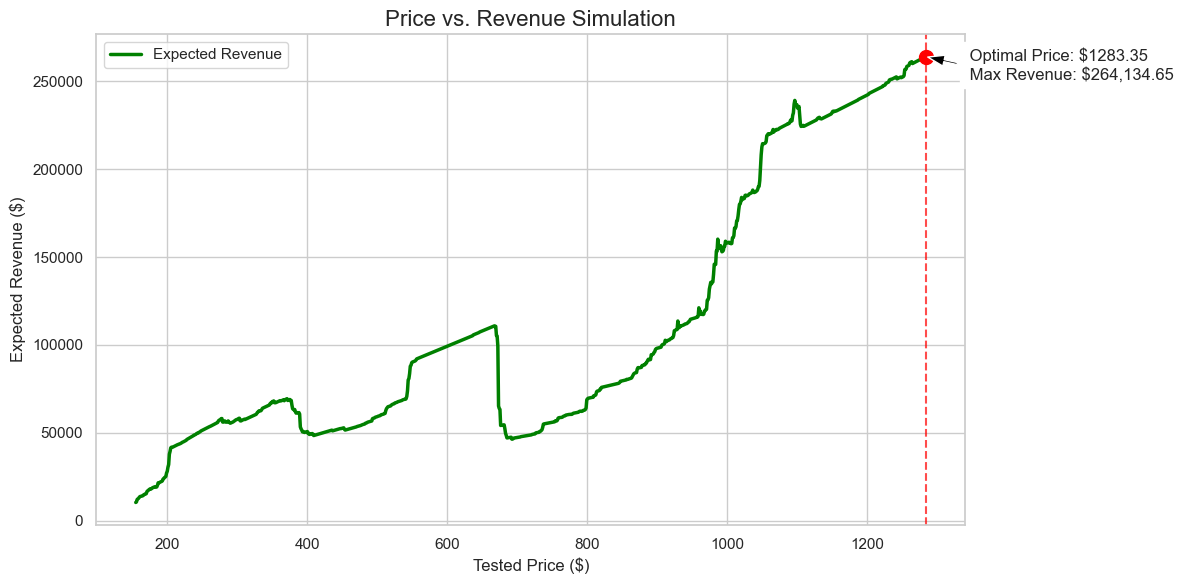


🏆 REALISTIC SIMULATION RESULTS 🏆
Optimal Price: $1283.35
Expected Demand: 206 units
Maximum Expected Revenue: $264,134.65


In [5]:

# 1. Load the dataset (since we haven't loaded it in this notebook yet!)
data_path = '../data/processed/cleaned_retail_sales.csv'
df = pd.read_csv(data_path)

# 2. Find the historical boundaries for this specific subcategory
historical_data = df[df['subcategory'] == sample_product['subcategory']]
max_historical_price = historical_data['price'].max()
min_historical_price = historical_data['price'].min()

print(f"--- Historical Data for {sample_product['subcategory']} ---")
print(f"Lowest price ever sold: ${min_historical_price:.2f}")
print(f"Highest price ever sold: ${max_historical_price:.2f}")
print("-" * 45)

# 3. Run the simulation ONLY within this realistic boundary
results_df, best_result = recommend_optimal_price(
    product_profile=sample_product,
    model=rf_model,
    min_price=min_historical_price,
    max_price=max_historical_price,
    step_size=1.0
)

print("\n🏆 REALISTIC SIMULATION RESULTS 🏆")
print(f"Optimal Price: ${best_result['price']:.2f}")
print(f"Expected Demand: {best_result['predicted_demand']:.0f} units")
print(f"Maximum Expected Revenue: ${best_result['expected_revenue']:,.2f}")

In [6]:
import pandas as pd

# Use ../ to go up one folder level first!
df = pd.read_csv('../data/processed/cleaned_retail_sales.csv')

# Save it as a compressed Parquet file!
df.to_parquet('../data/processed/cleaned_retail_sales.parquet', index=False)

print("Conversion complete! Check your processed folder.")

Conversion complete! Check your processed folder.


In [1]:
import joblib
import os

print("Loading giant model...")
# Use ../ because you are running this inside the notebooks folder
model = joblib.load('../models/demand_prediction_model.pkl')

print("Compressing... This might take a minute.")
# compress=3 is the sweet spot for maximum squashing without slowing down the app
joblib.dump(model, '../models/demand_prediction_model_compressed.pkl', compress=3)

# Check the new size
size_mb = os.path.getsize('../models/demand_prediction_model_compressed.pkl') / (1024 * 1024)
print(f"Done! New model size: {size_mb:.2f} MB")

Loading giant model...
Compressing... This might take a minute.
Done! New model size: 101.92 MB


In [2]:
import joblib
import os

print("Loading giant model...")
model = joblib.load('../models/demand_prediction_model.pkl')

print("Applying maximum LZMA compression... (this may take a couple of minutes)")
# We are switching to 'lzma' and cranking the power up to 9 (maximum)
joblib.dump(model, '../models/demand_prediction_model_compressed.pkl', compress=('lzma', 9))

# Check the new size
size_mb = os.path.getsize('../models/demand_prediction_model_compressed.pkl') / (1024 * 1024)
print(f"Done! New model size: {size_mb:.2f} MB")

Loading giant model...
Applying maximum LZMA compression... (this may take a couple of minutes)
Done! New model size: 62.83 MB
